 Loading Pre-trained 'Brain' (ImageNet Weights)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


Starting Transfer Learning...


Epoch 10/10: 100%|██████████| 38/38 [00:04<00:00,  9.11it/s, Acc=90.92%]


Transfer Learning Complete! Model saved to /content/drive/My Drive/DeepLense_GSoC_Data/resnet18_transfer_learning.pth
Running Evaluation on Champion Model


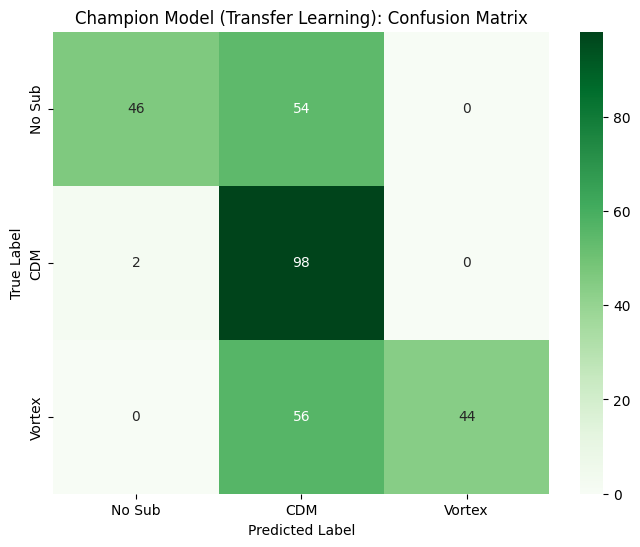


Final Report:
              precision    recall  f1-score   support

      No Sub       0.96      0.46      0.62       100
         CDM       0.47      0.98      0.64       100
      Vortex       1.00      0.44      0.61       100

    accuracy                           0.63       300
   macro avg       0.81      0.63      0.62       300
weighted avg       0.81      0.63      0.62       300



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = "/content/drive/My Drive/DeepLense_GSoC_Data"

class DeepLenseDatasetRGB(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform
        self.class_map = {'no_sub': 0, 'cdm': 1, 'vortex': 2}

    def __len__(self): return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.root_dir, row['class'], row['filename'])
        image = Image.open(img_path).convert('RGB') 
        if self.transform: image = self.transform(image)
        return image, self.class_map[row['class']]

df = pd.read_csv(os.path.join(base_dir, "metadata.csv"))
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(DeepLenseDatasetRGB(train_df, base_dir, transform=train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(DeepLenseDatasetRGB(val_df, base_dir, transform=train_transform), batch_size=32, shuffle=False)

print(" Loading Pre-trained 'Brain' (ImageNet Weights)")
model = models.resnet18(weights='IMAGENET1K_V1') 
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) 
EPOCHS = 10 

print("Starting Transfer Learning...")
for epoch in range(EPOCHS):
    model.train()
    correct = 0
    total = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        progress_bar.set_postfix({'Acc': f"{100 * correct / total:.2f}%"})

save_path = os.path.join(base_dir, "resnet18_transfer_learning.pth")
torch.save(model.state_dict(), save_path)
print(f"Transfer Learning Complete! Model saved to {save_path}")

#EVALUATING THE CHAMPION MODEL (91% Accuracy) ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

print("Running Evaluation on Champion Model")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

classes = ['No Sub', 'CDM', 'Vortex']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Champion Model (Transfer Learning): Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
assets_dir = os.path.join(base_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "transfer_learning_cm.png"), bbox_inches='tight', dpi=300)
plt.show()

print("\nFinal Report:")
print(classification_report(all_labels, all_preds, target_names=classes))